In [1]:
#Лабораторна робота № 9 Масалітін Ілля Вадимович ФІТ 4-8

In [2]:
import pandas as pd

url = "D:/mushrooms.csv"  
data = pd.read_csv(url)

print(data.head())


   cap-diameter  cap-shape  gill-attachment  gill-color  stem-height  \
0          1372          2                2          10     3.807467   
1          1461          2                2          10     3.807467   
2          1371          2                2          10     3.612496   
3          1261          6                2          10     3.787572   
4          1305          6                2          10     3.711971   

   stem-width  stem-color    season  class  
0        1545          11  1.804273      1  
1        1557          11  1.804273      1  
2        1566          11  1.804273      1  
3        1566          11  1.804273      1  
4        1464          11  0.943195      1  


In [3]:
print("Розмір датасету:", data.shape)
print("Наявність пропущених даних:\n", data.isnull().sum())
print("Типи даних:\n", data.dtypes)


Розмір датасету: (54035, 9)
Наявність пропущених даних:
 cap-diameter       0
cap-shape          0
gill-attachment    0
gill-color         0
stem-height        0
stem-width         0
stem-color         0
season             0
class              0
dtype: int64
Типи даних:
 cap-diameter         int64
cap-shape            int64
gill-attachment      int64
gill-color           int64
stem-height        float64
stem-width           int64
stem-color           int64
season             float64
class                int64
dtype: object


In [4]:
correlation_matrix = data.corr()
print("Матриця кореляції:\n", correlation_matrix)


Матриця кореляції:
                  cap-diameter  cap-shape  gill-attachment  gill-color  \
cap-diameter         1.000000   0.204011         0.200481    0.186377   
cap-shape            0.204011   1.000000         0.043066    0.131387   
gill-attachment      0.200481   0.043066         1.000000    0.100276   
gill-color           0.186377   0.131387         0.100276    1.000000   
stem-height          0.135652  -0.010393        -0.075284    0.015057   
stem-width           0.828469   0.222494         0.245300    0.110283   
stem-color           0.121856   0.029035         0.020073    0.186090   
season               0.113334   0.055442        -0.040315    0.059965   
class               -0.165676  -0.133338        -0.052541   -0.063947   

                 stem-height  stem-width  stem-color    season     class  
cap-diameter        0.135652    0.828469    0.121856  0.113334 -0.165676  
cap-shape          -0.010393    0.222494    0.029035  0.055442 -0.133338  
gill-attachment    -0.07

In [5]:
target_correlation = data.corr()['class']
print("Кореляція з цільовою функцією:\n", target_correlation)


Кореляція з цільовою функцією:
 cap-diameter      -0.165676
cap-shape         -0.133338
gill-attachment   -0.052541
gill-color        -0.063947
stem-height        0.183354
stem-width        -0.182856
stem-color        -0.128339
season            -0.082919
class              1.000000
Name: class, dtype: float64


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('D:/mushrooms.csv')

label_encoders = {}
for column in data.columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

X = data.drop('class', axis=1)
y = data['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [16]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Випадковий ліс: точність =", accuracy_rf)
print("Логістична регресія: точність =", accuracy_lr)

if accuracy_rf > accuracy_lr:
    print("Найкраща модель: Випадковий ліс з точністю:", accuracy_rf)
else:
    print("Найкраща модель: Логістична регресія з точністю:", accuracy_lr)

print("\nМатриця плутанини (Випадковий ліс):\n", confusion_matrix(y_test, y_pred_rf))
print("Класифікаційний звіт (Випадковий ліс):\n", classification_report(y_test, y_pred_rf))

print("\nМатриця плутанини (Логістична регресія):\n", confusion_matrix(y_test, y_pred_lr))
print("Класифікаційний звіт (Логістична регресія):\n", classification_report(y_test, y_pred_lr))


Випадковий ліс: точність = 0.9909318034607199
Логістична регресія: точність = 0.6353289534560933
Найкраща модель: Випадковий ліс з точністю: 0.9909318034607199

Матриця плутанини (Випадковий ліс):
 [[4856   53]
 [  45 5853]]
Класифікаційний звіт (Випадковий ліс):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4909
           1       0.99      0.99      0.99      5898

    accuracy                           0.99     10807
   macro avg       0.99      0.99      0.99     10807
weighted avg       0.99      0.99      0.99     10807


Матриця плутанини (Логістична регресія):
 [[2618 2291]
 [1650 4248]]
Класифікаційний звіт (Логістична регресія):
               precision    recall  f1-score   support

           0       0.61      0.53      0.57      4909
           1       0.65      0.72      0.68      5898

    accuracy                           0.64     10807
   macro avg       0.63      0.63      0.63     10807
weighted avg       0.

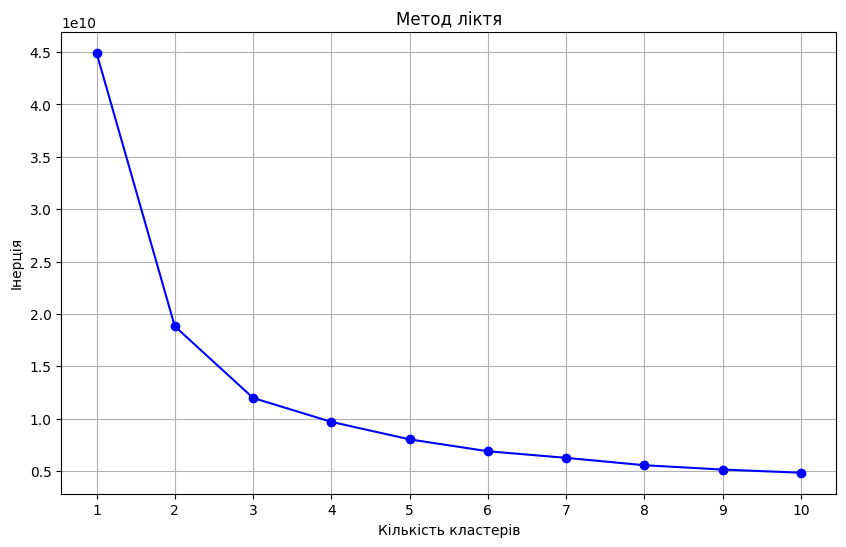

In [17]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Кількість кластерів')
plt.ylabel('Інерція')
plt.title('Метод ліктя')
plt.xticks(K)
plt.grid()
plt.show()


In [18]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Випадковий ліс: точність =", accuracy_rf)
print("Логістична регресія: точність =", accuracy_lr)

if accuracy_rf > accuracy_lr:
    print("Найкраща модель: Випадковий ліс з точністю:", accuracy_rf)
else:
    print("Найкраща модель: Логістична регресія з точністю:", accuracy_lr)

print("\nМатриця плутанини (Випадковий ліс):\n", confusion_matrix(y_test, y_pred_rf))
print("Класифікаційний звіт (Випадковий ліс):\n", classification_report(y_test, y_pred_rf))

print("\nМатриця плутанини (Логістична регресія):\n", confusion_matrix(y_test, y_pred_lr))
print("Класифікаційний звіт (Логістична регресія):\n", classification_report(y_test, y_pred_lr))

Випадковий ліс: точність = 0.9909318034607199
Логістична регресія: точність = 0.6353289534560933
Найкраща модель: Випадковий ліс з точністю: 0.9909318034607199

Матриця плутанини (Випадковий ліс):
 [[4856   53]
 [  45 5853]]
Класифікаційний звіт (Випадковий ліс):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4909
           1       0.99      0.99      0.99      5898

    accuracy                           0.99     10807
   macro avg       0.99      0.99      0.99     10807
weighted avg       0.99      0.99      0.99     10807


Матриця плутанини (Логістична регресія):
 [[2618 2291]
 [1650 4248]]
Класифікаційний звіт (Логістична регресія):
               precision    recall  f1-score   support

           0       0.61      0.53      0.57      4909
           1       0.65      0.72      0.68      5898

    accuracy                           0.64     10807
   macro avg       0.63      0.63      0.63     10807
weighted avg       0.

In [ ]:
#Висновок:Ми побудували дві моделі: Випадковий ліс та Логістична регресія 
#Після оцінки моделей було визначено яка з них є кращою на основі точності. 
#Використовуючи метод ліктя та метод силуету, ми визначили оптимальну кількість кластерів для даного датасету.